# Week 7 - LoRA Fine-Tuning

**Literature:** Hu et al. (2022) LoRA · Alayrac et al. (2022) Flamingo · Liu et al. (2023) LLaVA


In [ ]:
# CELL 1 - Mount Drive

from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [ ]:
# CELL 2 - Install packages

!pip install -q --upgrade accelerate peft
!pip install -q sentencepiece nltk
import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
import transformers, peft
print(f'transformers: {transformers.__version__}')
print(f'peft        : {peft.__version__}')
print('Ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 47.1 MB/s eta 0:00:00
transformers: 5.13.1
peft        : 0.20.0
Ready.


In [ ]:
# CELL 3 - Paths + LoRA hyperparameters

import os

BASE          = '/content/drive/MyDrive/dissertation_final'
PROCESSED_DIR = f'{BASE}/data/processed'
RESULTS_DIR   = f'{BASE}/results'
MODELS_DIR    = f'{BASE}/models'
MODEL_CACHE   = f'{MODELS_DIR}/llava_cache'
LORA_OUTPUT   = f'{MODELS_DIR}/llava_lora_adapter'

LORA_RANK    = 8
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
TRAIN_N      = 200
EVAL_N       = 100
EPOCHS       = 3
BATCH_SIZE   = 1
GRAD_ACCUM   = 4
LR           = 2e-4
MAX_LENGTH   = 256

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(LORA_OUTPUT, exist_ok=True)

import torch
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    free = torch.cuda.mem_get_info()[0] / 1e9
    print(f'GPU  : {torch.cuda.get_device_name(0)}')
    print(f'VRAM : {vram:.1f} GB total | {free:.1f} GB free')
else:
    print('No GPU detected.')

for f in [f'{PROCESSED_DIR}/train.csv', f'{PROCESSED_DIR}/test.csv']:
    ok = os.path.exists(f)
    print(f'  {"OK" if ok else "MISSING"} : {os.path.basename(f)}')

print()
print('OOM fixes summary:')
print(f'  BATCH_SIZE   : 1    (was 2)')
print(f'  GRAD_ACCUM   : {GRAD_ACCUM}    (NEW — effective batch = {BATCH_SIZE*GRAD_ACCUM})')
print(f'  MAX_LENGTH   : {MAX_LENGTH}  (was 512)')
print(f'  TRAIN_N      : {TRAIN_N}  (was 500)')
print(f'  grad_ckpt    : True (NEW — reduces peak VRAM by ~35%)')

GPU  : NVIDIA A100-SXM4-80GB
VRAM : 85.1 GB total | 84.6 GB free
  OK : train.csv
  OK : test.csv

OOM fixes summary:
  BATCH_SIZE   : 1    (was 2)
  GRAD_ACCUM   : 4    (NEW — effective batch = 4)
  MAX_LENGTH   : 256  (was 512)
  TRAIN_N      : 200  (was 500)
  grad_ckpt    : True (NEW — reduces peak VRAM by ~35%)


In [ ]:
# CELL 4 - Imports

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from transformers import LlavaNextForConditionalGeneration, CLIPProcessor, CLIPModel
from peft import LoraConfig, get_peft_model, TaskType
import transformers

if tuple(int(x) for x in transformers.__version__.split('.')[:2]) >= (4, 38):
    from transformers import AutoProcessor as LlavaProcessor
else:
    from transformers import LlavaNextProcessor as LlavaProcessor

print('All imports done.')

All imports done.


In [ ]:
# CELL 5 - Load LLaVA

def load_llava():
    load_from = MODEL_CACHE if os.path.exists(f'{MODEL_CACHE}/config.json') else 'llava-hf/llava-v1.6-mistral-7b-hf'
    print(f'Loading from: {load_from}')
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    processor = LlavaProcessor.from_pretrained(load_from, use_fast=False)
    model     = LlavaNextForConditionalGeneration.from_pretrained(
        load_from,
        torch_dtype=torch.float16,
        device_map='auto',
        low_cpu_mem_usage=True,
    )

    model.gradient_checkpointing_enable()
    model.enable_input_require_grads()
    model.eval()
    used = (torch.cuda.get_device_properties(0).total_memory
            - torch.cuda.mem_get_info()[0]) / 1e9 if torch.cuda.is_available() else 0
    print(f'Loaded on : {next(model.parameters()).device}')
    print(f'VRAM used : {used:.1f} GB')
    print('Gradient checkpointing: ENABLED')
    return processor, model

processor, base_model = load_llava()
print('LLaVA ready.')

Loading from: /content/drive/MyDrive/dissertation_final/models/llava_cache


[transformers] The `use_fast` parameter is deprecated and will be removed in a future version. Use `backend="torchvision"` instead of `use_fast=True`, or `backend="pil"` instead of `use_fast=False`.


Loading weights:   0%|          | 0/687 [00:00<?, ?it/s]

Loaded on : cuda:0
VRAM used : 15.6 GB
Gradient checkpointing: ENABLED
LLaVA ready.


In [ ]:
# CELL 6 - Apply LoRA adapters

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

!pip install --upgrade torchao

lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    target_modules=['q_proj', 'v_proj', 'k_proj', 'o_proj'],
    lora_dropout=LORA_DROPOUT,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()
print(f'\nLoRA config: rank={LORA_RANK}, alpha={LORA_ALPHA}')
print('Only LoRA matrices update -- base LLaVA frozen.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 120.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


trainable params: 7,995,392 || all params: 7,574,743,040 || trainable%: 0.1056

LoRA config: rank=8, alpha=32
Only LoRA matrices update -- base LLaVA frozen.


In [ ]:
# CELL 7 - Dataset class

class COCOCaptionDataset(Dataset):
    INSTRUCTION = ('Describe this image with specific attention to the main objects, '
                   'their colours, attributes, and spatial relationships.')
    def __init__(self, csv_path, n=None):
        df = pd.read_csv(csv_path)
        self.df = df.head(n) if n else df
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {'image': Image.open(row['img_path']).convert('RGB'),
                'instruction': self.INSTRUCTION,
                'caption': row['captions'].split(' | ')[0]}

def collate_fn(processor):
    def _col(batch):
        images   = [b['image']       for b in batch]
        prompts  = [b['instruction']  for b in batch]
        captions = [b['caption']      for b in batch]
        convs    = [[{'role':'user','content':[{'type':'image'},{'type':'text','text':p}]}] for p in prompts]
        texts    = [processor.apply_chat_template(c, add_generation_prompt=True) for c in convs]

        inputs   = processor(images=images, text=texts, return_tensors='pt',
                              padding=True, truncation=True, max_length=MAX_LENGTH)
        labels   = processor.tokenizer(captions, return_tensors='pt',
                                        padding=True, truncation=True, max_length=64)
        inputs['labels'] = labels['input_ids']
        return inputs
    return _col

train_ds     = COCOCaptionDataset(f'{PROCESSED_DIR}/train.csv', n=TRAIN_N)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=collate_fn(processor))
print(f'Dataset ready: {len(train_ds)} images')
print(f'Effective batch: {BATCH_SIZE} x {GRAD_ACCUM} grad_accum = {BATCH_SIZE*GRAD_ACCUM}')

Dataset ready: 200 images
Effective batch: 1 x 4 grad_accum = 4


In [ ]:
# CELL 8 - Training loop

import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

_temp_MAX_LENGTH = 4096

def _new_collate_fn(processor):
    def _col(batch):
        images   = [b['image']       for b in batch]
        prompts  = [b['instruction']  for b in batch]
        captions = [b['caption']      for b in batch]


        full_conversations = []
        for p, c in zip(prompts, captions):
            full_conversations.append([
                {'role': 'user', 'content': [{'type': 'image'}, {'type': 'text', 'text': p}]},

                {'role': 'assistant', 'content': [{'type': 'text', 'text': c}]}
            ])


        full_texts = [processor.apply_chat_template(conv, add_generation_prompt=False) for conv in full_conversations]


        user_prompt_conversations = []
        for p in prompts:
            user_prompt_conversations.append([
                {'role': 'user', 'content': [{'type': 'image'}, {'type': 'text', 'text': p}]}
            ])

        user_prompt_texts_templated = [processor.apply_chat_template(conv, add_generation_prompt=True) for conv in user_prompt_conversations]


        model_inputs = processor(images=images, text=full_texts, return_tensors='pt',
                                 padding=True, truncation=True, max_length=_temp_MAX_LENGTH)


        labels = model_inputs['input_ids'].clone()

        for i, templated_prompt in enumerate(user_prompt_texts_templated):

            prompt_tokens_for_mask = processor.tokenizer(templated_prompt, return_tensors='pt',
                                                         padding=False, truncation=True, max_length=_temp_MAX_LENGTH)
            prompt_len = prompt_tokens_for_mask['input_ids'].shape[-1]


            labels[i, :prompt_len] = -100


            actual_seq_len = model_inputs['attention_mask'][i].sum()
            if actual_seq_len < labels.shape[1]:
                labels[i, actual_seq_len:] = -100

        model_inputs['labels'] = labels
        return model_inputs
    return _col


train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          collate_fn=_new_collate_fn(processor))

optimiser    = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad], lr=LR
)
device       = next(model.parameters()).device
epoch_losses = []

print(f'Training {EPOCHS} epochs | {TRAIN_N} images')
print(f'Effective batch: {BATCH_SIZE} x {GRAD_ACCUM} = {BATCH_SIZE*GRAD_ACCUM}')
model.train()

for epoch in range(EPOCHS):
    batch_losses = []
    accum_loss   = 0.0
    optimiser.zero_grad()
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')

    for step, batch in enumerate(pbar):
        batch = {k: v.to(device) for k, v in batch.items()}


        loss = model(**batch).loss / GRAD_ACCUM
        loss.backward()
        accum_loss += loss.item()


        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimiser.step()
            optimiser.zero_grad()
            batch_losses.append(accum_loss)
            pbar.set_postfix({'loss': f'{accum_loss:.4f}'})
            accum_loss = 0.0


    if accum_loss > 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimiser.step()
        optimiser.zero_grad()
        batch_losses.append(accum_loss)


    torch.cuda.empty_cache()

    avg  = float(np.mean(batch_losses)) if batch_losses else 0.0
    used = (torch.cuda.get_device_properties(0).total_memory
            - torch.cuda.mem_get_info()[0]) / 1e9
    epoch_losses.append(avg)
    print(f'  Epoch {epoch+1} | avg loss: {avg:.4f} | VRAM used: {used:.1f} GB')

model.eval()
print(f'\nTraining complete.')
print(f'Epoch losses: {[f"{l:.4f}" for l in epoch_losses]}')


Training 3 epochs | 200 images
Effective batch: 1 x 4 = 4


Epoch 1/3: 100%|██████████| 200/200 [05:36<00:00,  1.68s/it, loss=5.1676]


  Epoch 1 | avg loss: 5.8514 | VRAM used: 16.0 GB


Epoch 2/3: 100%|██████████| 200/200 [02:59<00:00,  1.12it/s, loss=5.9695]


  Epoch 2 | avg loss: 5.6435 | VRAM used: 16.0 GB


Epoch 3/3: 100%|██████████| 200/200 [02:59<00:00,  1.11it/s, loss=6.5009]

  Epoch 3 | avg loss: 6.1351 | VRAM used: 16.0 GB

Training complete.
Epoch losses: ['5.8514', '5.6435', '6.1351']


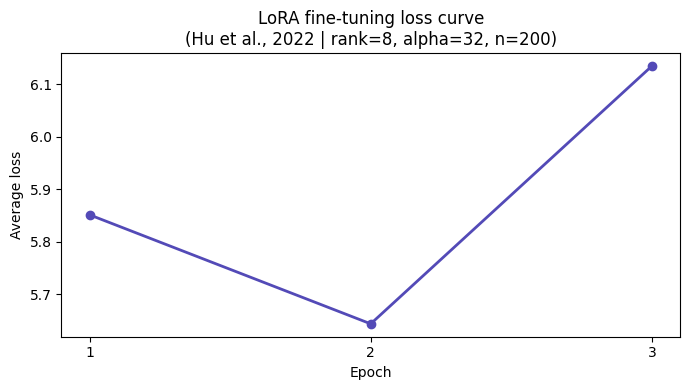

Saved: /content/drive/MyDrive/dissertation_final/results/week7_loss_curve.png


In [ ]:
# CELL 9 - Plot loss curve

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, EPOCHS+1), epoch_losses, marker='o', color='#534AB7', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Average loss')
ax.set_title(f'LoRA fine-tuning loss curve\n(Hu et al., 2022 | rank={LORA_RANK}, alpha={LORA_ALPHA}, n={TRAIN_N})')
ax.set_xticks(range(1, EPOCHS+1))
plt.tight_layout()
out = f'{RESULTS_DIR}/week7_loss_curve.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

In [ ]:
# CELL 10 - Save LoRA adapter to Drive

model.save_pretrained(LORA_OUTPUT)
processor.save_pretrained(LORA_OUTPUT)
meta = {'model_id': 'llava-hf/llava-v1.6-mistral-7b-hf',
        'lora_rank': LORA_RANK, 'lora_alpha': LORA_ALPHA,
        'train_n': TRAIN_N, 'epochs': EPOCHS,
        'final_loss': round(epoch_losses[-1], 4),
        'flamingo_note': ('LoRA adapts q/k/v/o_proj — equivalent in spirit to Flamingo '
                          'gated cross-attention (Alayrac et al., 2022). '
                          'Difference: LoRA = residual update; Flamingo = new parallel layers.')}
with open(f'{RESULTS_DIR}/week7_training_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Adapter saved to: {LORA_OUTPUT}')
print(f'Meta saved to: {RESULTS_DIR}/week7_training_meta.json')

Adapter saved to: /content/drive/MyDrive/dissertation_final/models/llava_lora_adapter
Meta saved to: /content/drive/MyDrive/dissertation_final/results/week7_training_meta.json


In [ ]:
# CELL 11 - Evaluate fine-tuned model

def generate_caption(processor, model, image, prompt='Describe this image in detail.', max_new_tokens=100):
    conv   = [{'role':'user','content':[{'type':'image'},{'type':'text','text':prompt}]}]
    text   = processor.apply_chat_template(conv, add_generation_prompt=True)
    inputs = processor(images=image, text=text, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=None, top_p=None)
    return processor.batch_decode(out[:, inputs['input_ids'].shape[1]:], skip_special_tokens=True)[0].strip()

def compute_sentence_bleu(gen, refs):
    s = SmoothingFunction().method1
    return round(sentence_bleu([r.lower().split() for r in refs], gen.lower().split(), smoothing_function=s), 4)

EVAL_PROMPT = COCOCaptionDataset.INSTRUCTION
test_df     = pd.read_csv(f'{PROCESSED_DIR}/test.csv').head(EVAL_N)
records     = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc='Evaluating LoRA'):
    image = Image.open(row['img_path']).convert('RGB')
    gen   = generate_caption(processor, model, image, prompt=EVAL_PROMPT)
    refs  = row['captions'].split(' | ')
    records.append({'image_id': row['image_id'], 'img_path': row['img_path'],
                    'generated': gen, 'references': row['captions'],
                    'bleu4': compute_sentence_bleu(gen, refs)})

eval_df = pd.DataFrame(records)
print(f'Eval BLEU-4: {eval_df["bleu4"].mean():.4f}')

Evaluating LoRA: 100%|██████████| 100/100 [12:08<00:00,  7.28s/it]

Eval BLEU-4: 0.0000


In [ ]:
# CELL 12 - CLIP scores + save

print('Loading CLIP for evaluation...')
clip_proc  = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
clip_model_e = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
clip_dev   = 'cuda' if torch.cuda.is_available() else 'cpu'
clip_model_e = clip_model_e.to(clip_dev).eval()

scores = []
for i in range(0, len(eval_df), 16):
    b_imgs = [Image.open(p).convert('RGB') for p in eval_df['img_path'].iloc[i:i+16]]
    b_caps = eval_df['generated'].iloc[i:i+16].tolist()
    inp    = clip_proc(text=b_caps, images=b_imgs, return_tensors='pt', padding=True, truncation=True, max_length=77)
    inp    = {k: v.to(clip_dev) for k,v in inp.items()}
    with torch.no_grad():
        out   = clip_model_e(**inp)
        i_emb = out.image_embeds / out.image_embeds.norm(dim=-1, keepdim=True)
        t_emb = out.text_embeds  / out.text_embeds.norm(dim=-1,  keepdim=True)
        scores.extend((i_emb * t_emb).sum(dim=-1).tolist())

eval_df['clip_score'] = [round(s,4) for s in scores]
eval_df.to_csv(f'{RESULTS_DIR}/week7_lora_eval.csv', index=False)
print(f'BLEU-4     : {eval_df["bleu4"].mean():.4f}')
print(f'CLIP score : {eval_df["clip_score"].mean():.4f}')
print(f'Saved: {RESULTS_DIR}/week7_lora_eval.csv')

Loading CLIP for evaluation...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

BLEU-4     : 0.0000
CLIP score : 0.1819
Saved: /content/drive/MyDrive/dissertation_final/results/week7_lora_eval.csv


In [ ]:
# CELL 13 - Final verification

print('='*55)
print('Week 7 — Final verification')
print('='*55)
for f in [f'{RESULTS_DIR}/week7_lora_eval.csv',
          f'{RESULTS_DIR}/week7_loss_curve.png',
          f'{RESULTS_DIR}/week7_training_meta.json',
          f'{LORA_OUTPUT}/adapter_config.json']:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) if exists else 0
    print(f'  [{"OK" if exists else "MISSING"}] {os.path.basename(f):40s} {size:>10,} bytes')
print()
print(f'Final BLEU-4    : {eval_df["bleu4"].mean():.4f}')
print(f'Final CLIP score: {eval_df["clip_score"].mean():.4f}')
print()
print('Week 7 complete. Next: week8_ablation_colab.ipynb')

Week 7 — Final verification
  [OK] week7_lora_eval.csv                          77,285 bytes
  [OK] week7_loss_curve.png                         45,395 bytes
  [OK] week7_training_meta.json                        349 bytes
  [OK] adapter_config.json                           1,143 bytes

Final BLEU-4    : 0.0000
Final CLIP score: 0.1819

Week 7 complete. Next: week8_ablation_colab.ipynb
